In [1]:
!curl -O https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  8.31M 100  8.31M   0      0 48.53M      0                              0
100  8.31M 100  8.31M   0      0 48.50M      0                              0
100  8.31M 100  8.31M   0      0 48.49M      0                              0
x korean-english-park.train.en
x korean-english-park.train.ko


In [2]:
import os

# 주피터 커널의 작업 위치를 10 폴더로 이동
os.chdir('D:/vscode/aiffel/2026/09/10')

# 현재 이동한 위치 확인
print("현재 파이썬 작업 경로:", os.getcwd())

현재 파이썬 작업 경로: D:\vscode\aiffel\2026\09\10


In [3]:
# 로컬 상대 경로 설정
data_dir = "./"
ko_path = os.path.join(data_dir, "korean-english-park.train.ko")
en_path = os.path.join(data_dir, "korean-english-park.train.en")

# 한글 및 영어 데이터 로드
with open(ko_path, "r", encoding="utf-8") as f:
    raw_ko = [line.strip() for line in f.readlines()]

with open(en_path, "r", encoding="utf-8") as f:
    raw_en = [line.strip() for line in f.readlines()]

print(f"✅ 로컬 데이터 로드 완료!")
print(f"전체 한글 문장 수: {len(raw_ko)}")
print(f"전체 영어 문장 수: {len(raw_en)}\n")

# 데이터 샘플 확인
for i in range(3):
    print(f"[{i+1}] KO: {raw_ko[i]}")
    print(f"    EN: {raw_en[i]}\n")

✅ 로컬 데이터 로드 완료!
전체 한글 문장 수: 94123
전체 영어 문장 수: 94123

[1] KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
    EN: Much of personal computing is about "can you top this?"

[2] KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
    EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

[3] KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
    EN: Like all optical mice, But it also doesn't need a desk.



In [4]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split

MAX_KO_LEN = 100
MAX_EN_LEN = 200

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. HTML 태그 제거
    text = re.sub(r'<[^>]+>', '', text)
    # 2. 줄바꿈, 탭을 공백으로 전환 후 연속 공백 축소
    text = re.sub(r'[\r\n\t]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 1. DataFrame 생성 및 결측치 제거
df = pd.DataFrame({'ko': raw_ko, 'en': raw_en}).dropna()

# 2. 텍스트 정제 (중복/길이 필터링보다 먼저 수행)
df['ko'] = df['ko'].apply(clean_text)
df['en'] = df['en'].apply(clean_text)

# 3. 정제 후 생성된 빈 문자열 제거 및 중복 제거
df = df[(df['ko'] != '') & (df['en'] != '')]
df.drop_duplicates(subset=['ko'], inplace=True)
df.drop_duplicates(subset=['en'], inplace=True)

# 4. 길이 기반 필터링 (글자 수 기준)
df = df[
    (df['ko'].str.len() >= 10) & (df['ko'].str.len() <= MAX_KO_LEN) &
    (df['en'].str.len() >= 10) & (df['en'].str.len() <= MAX_EN_LEN)
]

# 5. Train / Valid 세트 분할
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"✅ 최종 학습 데이터: {len(train_df)}개")
print(f"✅ 최종 검증 데이터: {len(val_df)}개")

✅ 최종 학습 데이터: 48616개
✅ 최종 검증 데이터: 12155개


=== 한글 문장 길이 통계 ===
최소: 10, 최대: 100, 평균: 57.1, 중앙값: 57.0
90%지점: 84.0, 95%지점: 91.0, 99%지점: 98.0

=== 영어 문장 길이 통계 ===
최소: 10, 최대: 200, 평균: 115.7, 중앙값: 115.0
90%지점: 175.0, 95%지점: 186.0, 99%지점: 197.0



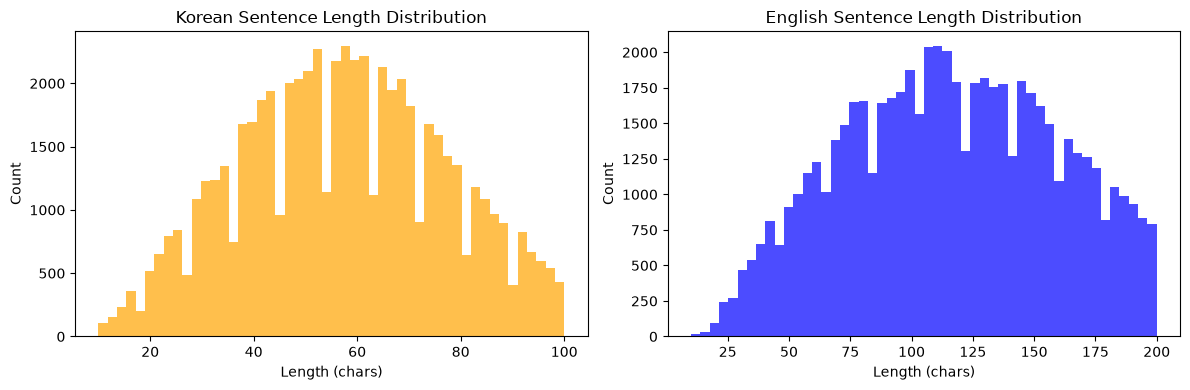

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 글자 수 길이 계산
ko_lens = df['ko'].str.len()
en_lens = df['en'].str.len()

# 주요 백분위수(Percentile) 출력
print("=== 한글 문장 길이 통계 ===")
print(f"최소: {np.min(ko_lens)}, 최대: {np.max(ko_lens)}, 평균: {np.mean(ko_lens):.1f}, 중앙값: {np.median(ko_lens):.1f}")
print(f"90%지점: {np.percentile(ko_lens, 90):.1f}, 95%지점: {np.percentile(ko_lens, 95):.1f}, 99%지점: {np.percentile(ko_lens, 99):.1f}\n")

print("=== 영어 문장 길이 통계 ===")
print(f"최소: {np.min(en_lens)}, 최대: {np.max(en_lens)}, 평균: {np.mean(en_lens):.1f}, 중앙값: {np.median(en_lens):.1f}")
print(f"90%지점: {np.percentile(en_lens, 90):.1f}, 95%지점: {np.percentile(en_lens, 95):.1f}, 99%지점: {np.percentile(en_lens, 99):.1f}\n")

# 시각화 (히스토그램)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(ko_lens, bins=50, color='orange', alpha=0.7)
plt.title('Korean Sentence Length Distribution')
plt.xlabel('Length (chars)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(en_lens, bins=50, color='blue', alpha=0.7)
plt.title('English Sentence Length Distribution')
plt.xlabel('Length (chars)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
import os
import pandas as pd
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Metaspace
from tokenizers.decoders import Metaspace as MetaspaceDecoder
from tokenizers.processors import TemplateProcessing

os.makedirs("tokenizer_data", exist_ok=True)

# 1. 안전한 문자열 형변환 후 파일 저장
with open("tokenizer_data/train_ko.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_df['ko'].astype(str)))

with open("tokenizer_data/train_en.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(train_df['en'].astype(str)))

VOCAB_SIZE = 8000
SPECIAL_TOKENS = ["[PAD]", "[SOS]", "[EOS]", "[UNK]"]

def build_bpe_tokenizer(corpus_file, vocab_size=VOCAB_SIZE):
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    
    # 2. Metaspace 적용: 공백을 ' ' 구분자로 보존하여 decode 시 공백 복원 가능하도록 설정
    tokenizer.pre_tokenizer = Metaspace(replacement=" ")
    tokenizer.decoder = MetaspaceDecoder(replacement=" ")
    
    trainer = BpeTrainer(
        vocab_size=vocab_size, 
        special_tokens=SPECIAL_TOKENS
    )
    
    tokenizer.train(files=[corpus_file], trainer=trainer)
    
    # 3. Post Processor 설정: encode() 호출 시 [SOS]와 [EOS]를 문장 앞뒤에 자동 추가
    sos_id = tokenizer.token_to_id("[SOS]")
    eos_id = tokenizer.token_to_id("[EOS]")
    tokenizer.post_processor = TemplateProcessing(
        single="[SOS] $A [EOS]",
        special_tokens=[
            ("[SOS]", sos_id),
            ("[EOS]", eos_id),
        ],
    )
    
    return tokenizer

print("한글 BPE 토크나이저 재학습 중...")
tokenizer_ko = build_bpe_tokenizer("tokenizer_data/train_ko.txt", vocab_size=VOCAB_SIZE)

print("영어 BPE 토크나이저 재학습 중...")
tokenizer_en = build_bpe_tokenizer("tokenizer_data/train_en.txt", vocab_size=VOCAB_SIZE)

tokenizer_ko.save("tokenizer_ko.json")
tokenizer_en.save("tokenizer_en.json")

print("✅ 수정된 토크나이저 재학습 완료!")

# 토큰 ID 검증
print("\n--- 토큰 ID 설정 검증 ---")
print("EN PAD ID:", tokenizer_en.token_to_id("[PAD]")) # 0
print("EN SOS ID:", tokenizer_en.token_to_id("[SOS]")) # 1
print("EN EOS ID:", tokenizer_en.token_to_id("[EOS]")) # 2
print("EN UNK ID:", tokenizer_en.token_to_id("[UNK]")) # 3

한글 BPE 토크나이저 재학습 중...
영어 BPE 토크나이저 재학습 중...
✅ 수정된 토크나이저 재학습 완료!

--- 토큰 ID 설정 검증 ---
EN PAD ID: 0
EN SOS ID: 1
EN EOS ID: 2
EN UNK ID: 3


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import random

import seaborn # Attention 시각화를 위해 필요!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print("device:", device)   # cuda 가 나와야 GPU 가 잘 연결된 것입니다.

2.5.1+cu121
device: cuda


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # d_model이 홀수일 경우를 대비해 짝수 크기로 분모 생성
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        # d_model이 홀수인 경우 cos 채널 슬라이싱 범위 자동 맞춤
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])

        # batch_first=True 전제: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: [batch_size, seq_len, d_model] (batch_first=True 필수)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [9]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        # 1. Attention Dropout 추가
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # Linear projection & Split heads: [batch_size, num_heads, seq_len, d_k]
        q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            # 2. 2D/3D 마스크 입력 시 4D 브로드캐스팅 가능하도록 자동 차원 확장
            if mask.dim() == 2:
                mask = mask.unsqueeze(1).unsqueeze(2)  # [batch_size, 1, 1, seq_len]
            elif mask.dim() == 3:
                mask = mask.unsqueeze(1)               # [batch_size, 1, seq_len, seq_len]

            # 3. FP16(AMP)에서도 안전한 마스킹 값(-1e4) 사용
            scores = scores.masked_fill(mask == 0, -1e4)

        # Softmax 후 Dropout 적용
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        context = torch.matmul(attn_weights, v)  # [batch_size, num_heads, q_len, d_k]
        
        # Concatenate heads & Final projection
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.out_proj(context)
        
        return output, attn_weights

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # [batch_size, seq_len, d_model] -> [batch_size, seq_len, d_ff] -> [batch_size, seq_len, d_model]
        # F.relu 대신 F.gelu 사용 권장
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

In [11]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(EncoderLayer, self).__init__()
        
        # 1. 핵심 부품 선언 (mha에도 dropout 파라미터 전달)
        self.mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        
        # 2. LayerNorm 및 Dropout 부품 선언
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # --- 서브레이어 1: Multi-Head Attention (Pre-LN 적용) ---
        # LayerNorm을 먼저 통과시킨 후 Attention 수행 -> 잔차 연결
        norm_x = self.norm1(x)
        attn_out, attn_weights = self.mha(norm_x, norm_x, norm_x, mask=mask)
        x = x + self.dropout1(attn_out)
        
        # --- 서브레이어 2: Position-wise Feed-Forward (Pre-LN 적용) ---
        # LayerNorm을 먼저 통과시킨 후 FFN 수행 -> 잔차 연결
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        
        return x, attn_weights

In [12]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, pad_idx=0):
        super(Encoder, self).__init__()
        self.d_model = d_model
        
        # 1. 단어 임베딩 레이어 (pad_idx 지정)
        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        
        # 2. 위치 인코딩 (파라미터 키워드 명시)
        self.pos_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        
        # 3. EncoderLayer 쌓기
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 4. Pre-LN 구조의 최종 LayerNorm
        self.norm = nn.LayerNorm(d_model)

    def forward(self, src, mask=None):
        # src: [batch_size, seq_len]
        
        # 1. 임베딩 연산 & Scale 조절 (math.sqrt 사용으로 float32 유지)
        out = self.tok_embedding(src) * math.sqrt(self.d_model)
        
        # 2. Positional Encoding 적용 (내부에서 Dropout 처리됨)
        out = self.pos_encoding(out)
        
        # 3. N개의 EncoderLayer 순차 통과
        for layer in self.layers:
            out, _ = layer(out, mask)
            
        # 4. Pre-LN 최종 정규화
        out = self.norm(out)
        
        return out  # [batch_size, seq_len, d_model]

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(DecoderLayer, self).__init__()
        
        # 1. MultiHeadAttention 객체 생성 시 dropout 파라미터 전달
        self.self_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.cross_attn = MultiHeadAttention(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.ffn = PositionwiseFeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)
        
        # 2. LayerNorm 및 Dropout 선언
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, enc_src, tgt_mask=None, src_mask=None):
        # --- 서브레이어 1: Masked Self-Attention (Pre-LN) ---
        norm_tgt = self.norm1(tgt)
        _tgt, self_attn_weights = self.self_attn(norm_tgt, norm_tgt, norm_tgt, mask=tgt_mask)
        tgt = tgt + self.dropout1(_tgt)
        
        # --- 서브레이어 2: Cross-Attention (Pre-LN) ---
        # Q(tgt)만 LayerNorm을 적용하고, K/V(enc_src)는 인코더 출력을 그대로 사용
        norm_tgt = self.norm2(tgt)
        _tgt, cross_attn_weights = self.cross_attn(Q=norm_tgt, K=enc_src, V=enc_src, mask=src_mask)
        tgt = tgt + self.dropout2(_tgt)
        
        # --- 서브레이어 3: Feed-Forward (Pre-LN) ---
        tgt = tgt + self.dropout3(self.ffn(self.norm3(tgt)))
        
        return tgt, self_attn_weights, cross_attn_weights

In [14]:
def generate_square_subsequent_mask(sz, device='cpu'):
    # torch.tril (하삼각 행렬): 자기 자신과 이전 토큰 위치만 True(1)로 설정
    # True: 참조 가능 (Valid), False: 미래 단어 가림 (Masked)
    mask = torch.tril(torch.ones((sz, sz), device=device)).bool()
    return mask

In [15]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=5000, dropout=0.1, pad_idx=0):
        super(Decoder, self).__init__()
        self.d_model = d_model
        
        # 1. 단어 임베딩 (pad_idx 지정)
        self.tok_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        
        # 2. 위치 인코딩 (키워드 인자 명시)
        self.pos_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        
        # 3. DecoderLayer 쌓기
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        self.norm = nn.LayerNorm(d_model)

    def forward(self, tgt, enc_src, tgt_mask=None, src_mask=None):
        # 1. 임베딩 연산 & Scale 조절 (math.sqrt 사용으로 float32 유지)
        out = self.tok_embedding(tgt) * math.sqrt(self.d_model)
        
        # 2. Positional Encoding 적용 (내부에서 Dropout 처리됨)
        out = self.pos_encoding(out)

        cross_attns = []

        # 3. N개의 DecoderLayer 순차 통과
        for layer in self.layers:
            out, self_attn, cross_attn = layer(out, enc_src, tgt_mask=tgt_mask, src_mask=src_mask)
            cross_attns.append(cross_attn)

        # 4. Pre-LN 최종 정규화
        out = self.norm(out)
        return out, cross_attns

In [16]:
import torch
import torch.nn as nn

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=5000, dropout=0.1, pad_idx=0):
        super(Transformer, self).__init__()
        self.pad_idx = pad_idx

        # 1. pad_idx를 인코더와 디코더에 키워드 인자로 전달
        self.encoder = Encoder(
            vocab_size=src_vocab_size, 
            d_model=d_model, 
            num_layers=num_layers, 
            num_heads=num_heads, 
            d_ff=d_ff, 
            max_len=max_len, 
            dropout=dropout, 
            pad_idx=pad_idx
        )
        self.decoder = Decoder(
            vocab_size=tgt_vocab_size, 
            d_model=d_model, 
            num_layers=num_layers, 
            num_heads=num_heads, 
            d_ff=d_ff, 
            max_len=max_len, 
            dropout=dropout, 
            pad_idx=pad_idx
        )
        self.generator = nn.Linear(d_model, tgt_vocab_size)
        
        # 2. Weight Tying: 디코더 임베딩과 Generator 가중치 공유 (논문 필수 스펙)
        self.generator.weight = self.decoder.tok_embedding.weight

    def make_pad_mask(self, q, k):
        return (k != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_subsequent_mask(self, tgt):
        tgt_len = tgt.size(1)
        subsequent_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        return subsequent_mask.unsqueeze(0).unsqueeze(1)

    def forward(self, src, tgt):
        # 1. 마스크 생성
        src_mask = self.make_pad_mask(src, src)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt)
        tgt_sub_mask = self.make_subsequent_mask(tgt)
        
        tgt_mask = tgt_pad_mask & tgt_sub_mask
        src_tgt_mask = self.make_pad_mask(tgt, src)
        
        # 2. 인코더 및 디코더 통과
        enc_src = self.encoder(src, src_mask)
        dec_out, cross_attns = self.decoder(tgt, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
        
        output = self.generator(dec_out)
        
        # 3. 어텐션 시각화를 위해 cross_attns 함께 반환
        return output, cross_attns

In [17]:
import os
import torch
from torch.utils.data import Dataset, DataLoader

# 1. 사전 토큰화 Dataset (수정됨)
class FastTranslationDataset(Dataset):
    def __init__(self, df, src_tokenizer, tgt_tokenizer, src_col='ko', tgt_col='en'):
        print("⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...")
        # __init__ 생성 시점에 전체 문장을 한 번만 토큰화하여 리스트에 저장
        self.src_data = [src_tokenizer.encode(str(text)).ids for text in df[src_col]]
        self.tgt_data = [tgt_tokenizer.encode(str(text)).ids for text in df[tgt_col]]
        print(f"✅ {len(self.src_data)}개 데이터 사전 토큰화 완료!")

    def __len__(self):
        return len(self.src_data)

    def __getitem__(self, idx):
        # 학습 루프에서는 미리 토큰화된 ID 리스트를 텐서로 변환하여 즉시 반환
        return (
            torch.tensor(self.src_data[idx], dtype=torch.long),
            torch.tensor(self.tgt_data[idx], dtype=torch.long)
        )

# 2. 안전한 배치 패딩 클래스 (기존 동일)
class PadCollate:
    def __init__(self, src_pad_idx, tgt_pad_idx):
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

    def __call__(self, batch):
        src_batch, tgt_batch = zip(*batch)
        src_pad = torch.nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=self.src_pad_idx)
        tgt_pad = torch.nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=self.tgt_pad_idx)
        return src_pad, tgt_pad

# 3. Dataset 및 Collate 객체 생성
train_dataset = FastTranslationDataset(train_df, tokenizer_ko, tokenizer_en)
val_dataset = FastTranslationDataset(val_df, tokenizer_ko, tokenizer_en)

src_pad_idx = tokenizer_ko.token_to_id("[PAD]")
tgt_pad_idx = tokenizer_en.token_to_id("[PAD]")
pad_collate = PadCollate(src_pad_idx, tgt_pad_idx)

# 4. DataLoader 고속화 설정 (수정됨)
BATCH_SIZE = 64
NUM_WORKERS = min(4, os.cpu_count())

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=pad_collate,
    num_workers=0,  # 💡 Windows Jupyter Notebook 환경에서는 0으로 설정해야 멈추지 않습니다!
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=pad_collate,
    num_workers=0,  # 💡 0으로 설정
    pin_memory=True
)

print(f"🚀 고속 DataLoader 생성 완료! (num_workers={NUM_WORKERS}, pin_memory=True)")
print(f"한국어 PAD ID: {src_pad_idx} | 영어 PAD ID: {tgt_pad_idx}")

⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...
✅ 48616개 데이터 사전 토큰화 완료!
⚡ 데이터셋 사전 토큰화(Pre-tokenization) 진행 중...
✅ 12155개 데이터 사전 토큰화 완료!
🚀 고속 DataLoader 생성 완료! (num_workers=4, pin_memory=True)
한국어 PAD ID: 0 | 영어 PAD ID: 0


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 단어장 크기 및 패딩 토큰 ID 설정
SRC_VOCAB_SIZE = tokenizer_ko.get_vocab_size()
TGT_VOCAB_SIZE = tokenizer_en.get_vocab_size()
PAD_IDX = tokenizer_ko.token_to_id("[PAD]")  # PAD_IDX 변수 정의

# 모델 하이퍼파라미터
D_MODEL = 512
NUM_LAYERS = 6
NUM_HEADS = 8
D_FF = 2048
DROPOUT = 0.1

# Transformer 모델 객체 생성
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

print(f"✅ 모델 생성 및 {device} 할당 완료!")
print(f"적용된 PAD_IDX: {PAD_IDX}")

✅ 모델 생성 및 cuda 할당 완료!
적용된 PAD_IDX: 0


In [19]:
def translate_sentence_fast(model, sentence, max_len=30):
    model.eval()

    # 0. 디코더(영어) 전용 특수 토큰 ID 명시적 추출
    sos_idx = tokenizer_en.token_to_id("[SOS]")
    eos_idx = tokenizer_en.token_to_id("[EOS]")
    pad_idx = tokenizer_en.token_to_id("[PAD]")

    with torch.no_grad():
        # 1. 인코더 입력 토큰화 (TemplateProcessing에 의해 [SOS], [EOS]가 자동 포함됨)
        src_tokens = tokenizer_ko.encode(sentence).ids
        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        
        # 2. 인코더 마스크 생성 및 인코더 통과
        src_mask = model.make_pad_mask(src_tensor, src_tensor)
        enc_src = model.encoder(src_tensor, src_mask)

        tgt_indices = [sos_idx]

        # 3. Auto-regressive 디코딩 루프
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=device)

            # 디코더 마스크 생성
            tgt_pad_mask = model.make_pad_mask(tgt_tensor, tgt_tensor)
            tgt_sub_mask = model.make_subsequent_mask(tgt_tensor)
            tgt_mask = tgt_pad_mask & tgt_sub_mask
            
            # Cross-Attention 마스크
            src_tgt_mask = model.make_pad_mask(tgt_tensor, src_tensor)

            # 디코더 연산 및 다음 토큰 확률 예측
            dec_out, _ = model.decoder(tgt_tensor, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
            logits = model.generator(dec_out)[:, -1, :] # [1, tgt_vocab_size]

            next_token = logits.argmax(dim=-1).item()
            tgt_indices.append(next_token)

            # EOS 토큰이 나오면 생성 종료
            if next_token == eos_idx:
                break

        # 4. 특수 토큰 제거 후 텍스트 복원
        decoded_tokens = [idx for idx in tgt_indices if idx not in (sos_idx, eos_idx, pad_idx)]
        translated = tokenizer_en.decode(decoded_tokens)
        
        return translated if translated.strip() else "(번역 결과 없음)"

In [20]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 1. 디렉토리 설정 및 모델 가중치 초기화
save_dir = "./checkpoints2"
os.makedirs(save_dir, exist_ok=True)
model = model.to(device)

def weights_init(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(weights_init)

# 2. 토크나이저 PAD_IDX 지정 및 손실 함수 / 옵티마이저 설정
PAD_IDX = tokenizer_en.token_to_id("[PAD]")
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Transformer Adam 옵티마이저 & Warmup 스케줄러 설정
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def rate(step, model_size=512, factor=1.0, warmup=2000):
    if step == 0:
        step = 1
    return factor * (model_size ** (-0.5) * min(step ** (-0.5), step * (warmup ** -1.5)))

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=lambda step: rate(step, model_size=512, factor=1.0, warmup=2000)
)

# 3. 매 에포크마다 추론할 테스트 문장
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# 4. 1 에포크 학습 함수
scaler = torch.cuda.amp.GradScaler()

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, epoch, total_epochs):
    model.train()
    epoch_loss = 0
    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Train", leave=False)

    for src, tgt in pbar:
        src, tgt = src.to(device, non_blocking=True), tgt.to(device, non_blocking=True)
        tgt_input, tgt_label = tgt[:, :-1], tgt[:, 1:]

        optimizer.zero_grad()

        # Mixed Precision 연산 적용
        with torch.cuda.amp.autocast():
            logits, _ = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_val = loss.item()
        epoch_loss += loss_val
        pbar.set_postfix({'loss': f'{loss_val:.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.6f}'})

    return epoch_loss / len(dataloader)


# 5. 1 에포크 검증 함수
def evaluate(model, dataloader, criterion, device, epoch, total_epochs):
    model.eval()
    epoch_loss = 0

    pbar = tqdm(dataloader, desc=f"Epoch [{epoch}/{total_epochs}] Eval ", leave=False)

    with torch.no_grad():
        for src, tgt in pbar:
            src, tgt = src.to(device), tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_label = tgt[:, 1:]

            # 튜플 언패킹
            logits, _ = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_label.reshape(-1))

            loss_val = loss.item()
            epoch_loss += loss_val

            pbar.set_postfix({'loss': f'{loss_val:.4f}'})

    return epoch_loss / len(dataloader)


# 6. 학습 / 검증 / 실시간 추론 실행 Loop
NUM_EPOCHS = 20
print("=== 학습 / 검증 / 에포크별 실시간 추론 진행 ===")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, criterion, device, epoch, NUM_EPOCHS)
    test_loss = evaluate(model, val_dataloader, criterion, device, epoch, NUM_EPOCHS)
    
    checkpoint_path = os.path.join(save_dir, f"transformer_epoch_{epoch}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'test_loss': test_loss
    }, checkpoint_path)
    
    print(f"\n==========================================")
    print(f" [ Epoch {epoch:02d}/{NUM_EPOCHS} ] | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"==========================================")
    
    for i, sentence in enumerate(test_sentences, 1):
        translated = translate_sentence_fast(model, sentence)
        print(f"  {i}. {sentence}")
        print(f"    ➔ {translated}")
    print()

print("✅ 학습 및 실시간 추론 실행 준비가 완료되었습니다!")

C:\Users\User\AppData\Local\Temp\ipykernel_19952\2064345658.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


=== 학습 / 검증 / 에포크별 실시간 추론 진행 ===


Epoch [1/20] Train:   0%|          | 0/760 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_19952\2064345658.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



 [ Epoch 01/20 ] | Train Loss: 6.8383 | Test Loss: 5.8926
  1. 오바마는 대통령이다.
    ➔ The United States is not not not not not not not not not not not not not not not not to the United States.
  2. 시민들은 도시 속에 산다.
    ➔ The new new government is a few years.
  3. 커피는 필요 없다.
    ➔ The new new government is not not not not not not not not to the country.
  4. 일곱 명의 사망자가 발생했다.
    ➔ The United States have been been been a year.




 [ Epoch 02/20 ] | Train Loss: 5.5143 | Test Loss: 5.1350
  1. 오바마는 대통령이다.
    ➔ Obama is the White House.
  2. 시민들은 도시 속에 산다.
    ➔ They are also also also also also also also also the most of the time.
  3. 커피는 필요 없다.
    ➔ But the move is not a little.
  4. 일곱 명의 사망자가 발생했다.
    ➔ The death toll was killed.



...


 [ Epoch 16/20 ] | Train Loss: 2.1249 | Test Loss: 4.2924
  1. 오바마는 대통령이다.
    ➔ Obama is in his inaugural address.
  2. 시민들은 도시 속에 산다.
    ➔ They are at the beach.
  3. 커피는 필요 없다.
    ➔ Did not some of the coffee.
  4. 일곱 명의 사망자가 발생했다.
    ➔ At least seven people were killed.




 [ Epoch 17/20 ] | Train Loss: 2.0106 | Test Loss: 4.3642
  1. 오바마는 대통령이다.
    ➔ Obama is the nominee for president.
  2. 시민들은 도시 속에 산다.
    ➔ The people are at the beach.
  3. 커피는 필요 없다.
    ➔ What is that you don't need.
  4. 일곱 명의 사망자가 발생했다.
    ➔ Twelve people were killed in the blast.




 [ Epoch 18/20 ] | Train Loss: 1.9043 | Test Loss: 4.4351
  1. 오바마는 대통령이다.
    ➔ Obama is the nominee for president.
  2. 시민들은 도시 속에 산다.
    ➔ They are the city's poor.
  3. 커피는 필요 없다.
    ➔ No reason for the interview is
  4. 일곱 명의 사망자가 발생했다.
    ➔ Seven people were killed in the blast.




 [ Epoch 19/20 ] | Train Loss: 1.8051 | Test Loss: 4.5110
  1. 오바마는 대통령이다.
    ➔ Obama also has the support of Obama.
  2. 시민들은 도시 속에 산다.
    ➔ They are the city's oldest live live hometown of the city's hometown of the capital.
  3. 커피는 필요 없다.
    ➔ What is you don't want to be?
  4. 일곱 명의 사망자가 발생했다.
    ➔ Seven people were killed.




 [ Epoch 20/20 ] | Train Loss: 1.7154 | Test Loss: 4.5743
  1. 오바마는 대통령이다.
    ➔ Obama has his campaign.
  2. 시민들은 도시 속에 산다.
    ➔ They are the city's oldest live hometown of the city's cities.
  3. 커피는 필요 없다.
    ➔ The coffee shouldn't be need to be
  4. 일곱 명의 사망자가 발생했다.
    ➔ Seven people were killed.

✅ 학습 및 실시간 추론 실행 준비가 완료되었습니다!


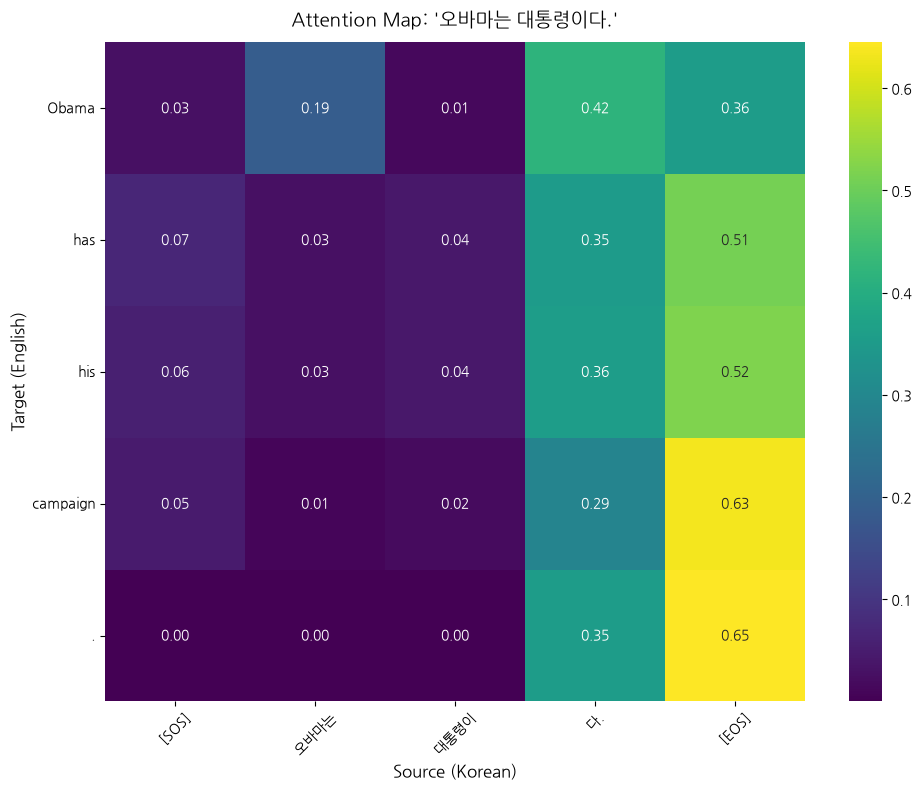

In [21]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import torch

def setup_korean_font():
    # 한글 폰트(나눔고딕) 설정 및 마이너스 깨짐 방지
    plt.rc('font', family='NanumGothic')
    plt.rc('axes', unicode_minus=False)

def plot_real_attention(sentence):
    setup_korean_font()
    
    model.to(device)
    model.eval()
    attention_list = []

    # 특수 토큰 ID 안전하게 가져오기
    en_sos_idx = tokenizer_en.token_to_id("[SOS]")
    en_eos_idx = tokenizer_en.token_to_id("[EOS]")
    en_pad_idx = tokenizer_en.token_to_id("[PAD]")

    with torch.no_grad():
        # 1. 인코더 입력 토큰화 (TemplateProcessing으로 SOS/EOS 자동 포함)
        src_tokens = tokenizer_ko.encode(sentence).ids
        src_tensor = torch.tensor([src_tokens], dtype=torch.long, device=device)
        
        src_mask = model.make_pad_mask(src_tensor, src_tensor)
        enc_src = model.encoder(src_tensor, src_mask)

        tgt_indices = [en_sos_idx]

        for _ in range(30):
            tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long, device=device)
            tgt_pad_mask = model.make_pad_mask(tgt_tensor, tgt_tensor)
            tgt_sub_mask = model.make_subsequent_mask(tgt_tensor)
            tgt_mask = tgt_pad_mask & tgt_sub_mask
            
            src_tgt_mask = model.make_pad_mask(tgt_tensor, src_tensor)

            dec_out, attns = model.decoder(tgt_tensor, enc_src, tgt_mask=tgt_mask, src_mask=src_tgt_mask)
            
            # 마지막 디코더 레이어의 어텐션 가중치 추출
            if isinstance(attns, (list, tuple)):
                last_attn = attns[-1]
            else:
                last_attn = attns

            # 8개 헤드 평균 -> [batch_size, tgt_len, src_len]
            mean_head_attn = last_attn.mean(dim=1) 
            last_token_attn = mean_head_attn[0, -1, :].cpu() 
            
            logits = model.generator(dec_out)[:, -1, :]
            next_token = logits.argmax(dim=-1).item()

            if next_token == en_eos_idx:
                break
                
            attention_list.append(last_token_attn)
            tgt_indices.append(next_token)

    # 2. Source 및 Target 라벨 추출 (서브워드 기호 정제)
    src_labels = []
    for idx in src_tokens:
        tok = tokenizer_ko.id_to_token(idx)
        tok = str(idx) if tok is None else tok.replace(' ', '').replace('Ġ', '').replace('##', '')
        src_labels.append(tok)

    tgt_labels = []
    for idx in tgt_indices[1:]:
        tok = tokenizer_en.id_to_token(idx)
        tok = str(idx) if tok is None else tok.replace(' ', '').replace('Ġ', '').replace('##', '')
        tgt_labels.append(tok)

    if not attention_list:
        print("⚠️ 생성된 토큰이 없어 어텐션 맵을 출력하지 않습니다.")
        return

    # 3. Attention 행렬 생성 및 시각화
    attn_matrix = torch.stack(attention_list[:len(tgt_labels)], dim=0).numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn_matrix, 
        xticklabels=src_labels, 
        yticklabels=tgt_labels, 
        cmap='viridis', 
        annot=True, 
        fmt=".2f"
    )

    plt.title(f"Attention Map: '{sentence}'", fontsize=14, pad=12)
    plt.xlabel("Source (Korean)", fontsize=12)
    plt.ylabel("Target (English)", fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("attention_map_real.png", dpi=300)
    plt.show()

# 실행
plot_real_attention("오바마는 대통령이다.")